In [2]:
import pandas as pd

wine = pd.read_csv(r'https://raw.githubusercontent.com/rickiepark/hg-mldl/master/wine.csv', low_memory=False)
print(wine.columns)

#데이터 전처리
wine.info()
wine.describe()

wine_input = wine[['alcohol', 'sugar', 'pH']]
wine_target = wine['class']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(wine_input, wine_target, stratify=wine_target, random_state=42, test_size=0.2)

#데이터 정규화
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#특성공학
# from sklearn.preprocessing import PolynomialFeatures
# pl = PolynomialFeatures(include_bias=False, degre)
# pl.fit(train_scaled)
# train_poly = pl.transform(train_scaled)
# test_poly = pl.transform(test_scaled)
# print(pl.get_feature_names_out())

#이중분류분석, 로지스틱회귀분석
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))
print()
print(lr.coef_, lr.intercept_)


Index(['alcohol', 'sugar', 'pH', 'class'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB
0.7827592842024245
0.7761538461538462

[[ 0.56665195  1.65194545 -0.71337272]] [1.78522766]


0.8458726188185491
0.8407692307692308


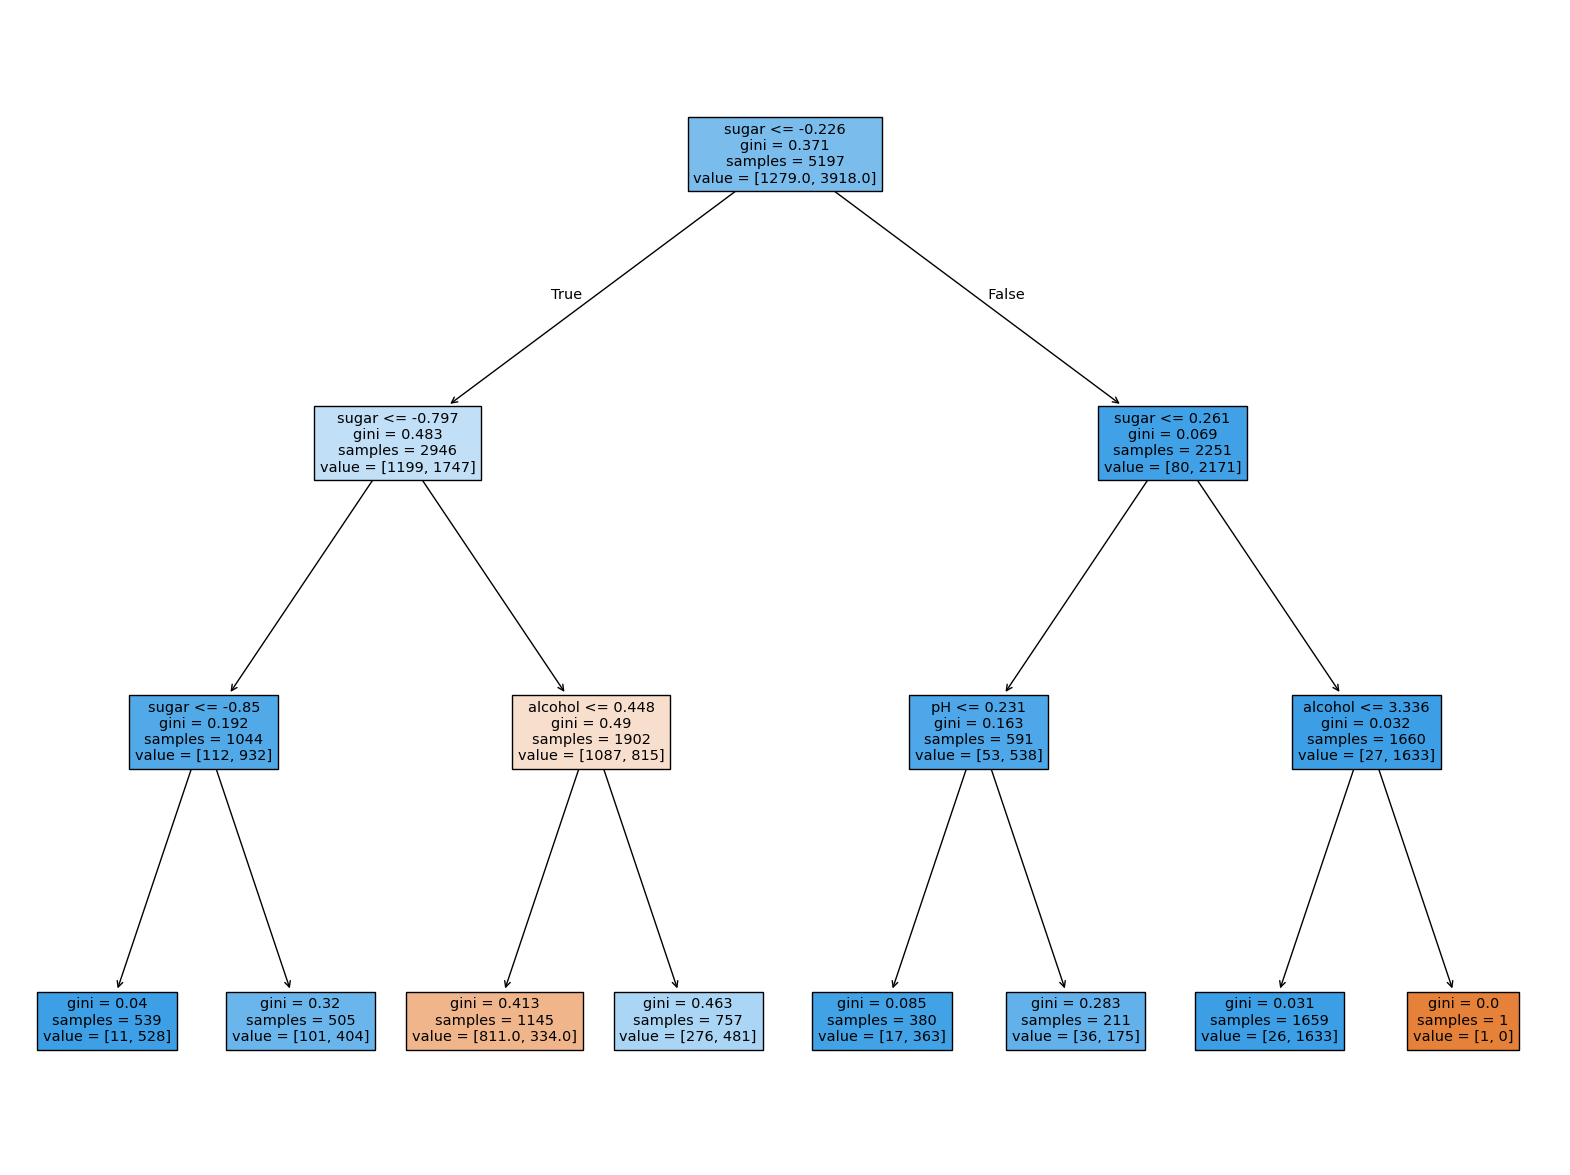

In [12]:
#결정트리모델(DecisionTree)
#비즈니스 의사 결정에서 판단 근거 제공과 설명력 높음
#노드(루트노드, 리프노드) 결정트리의 구성요소. 훈련 데이터 특성에 대한 테스트 표현(예: 당도가 -21보다 높은가?, )
#가지(True/False 노드에 대한 결과. )

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=train_input.columns)
plt.show()


0.8458726188185491
0.8407692307692308
[0. 1.]
['alcohol' 'sugar' 'pH']
[0.14086835 0.85360568 0.00552597]


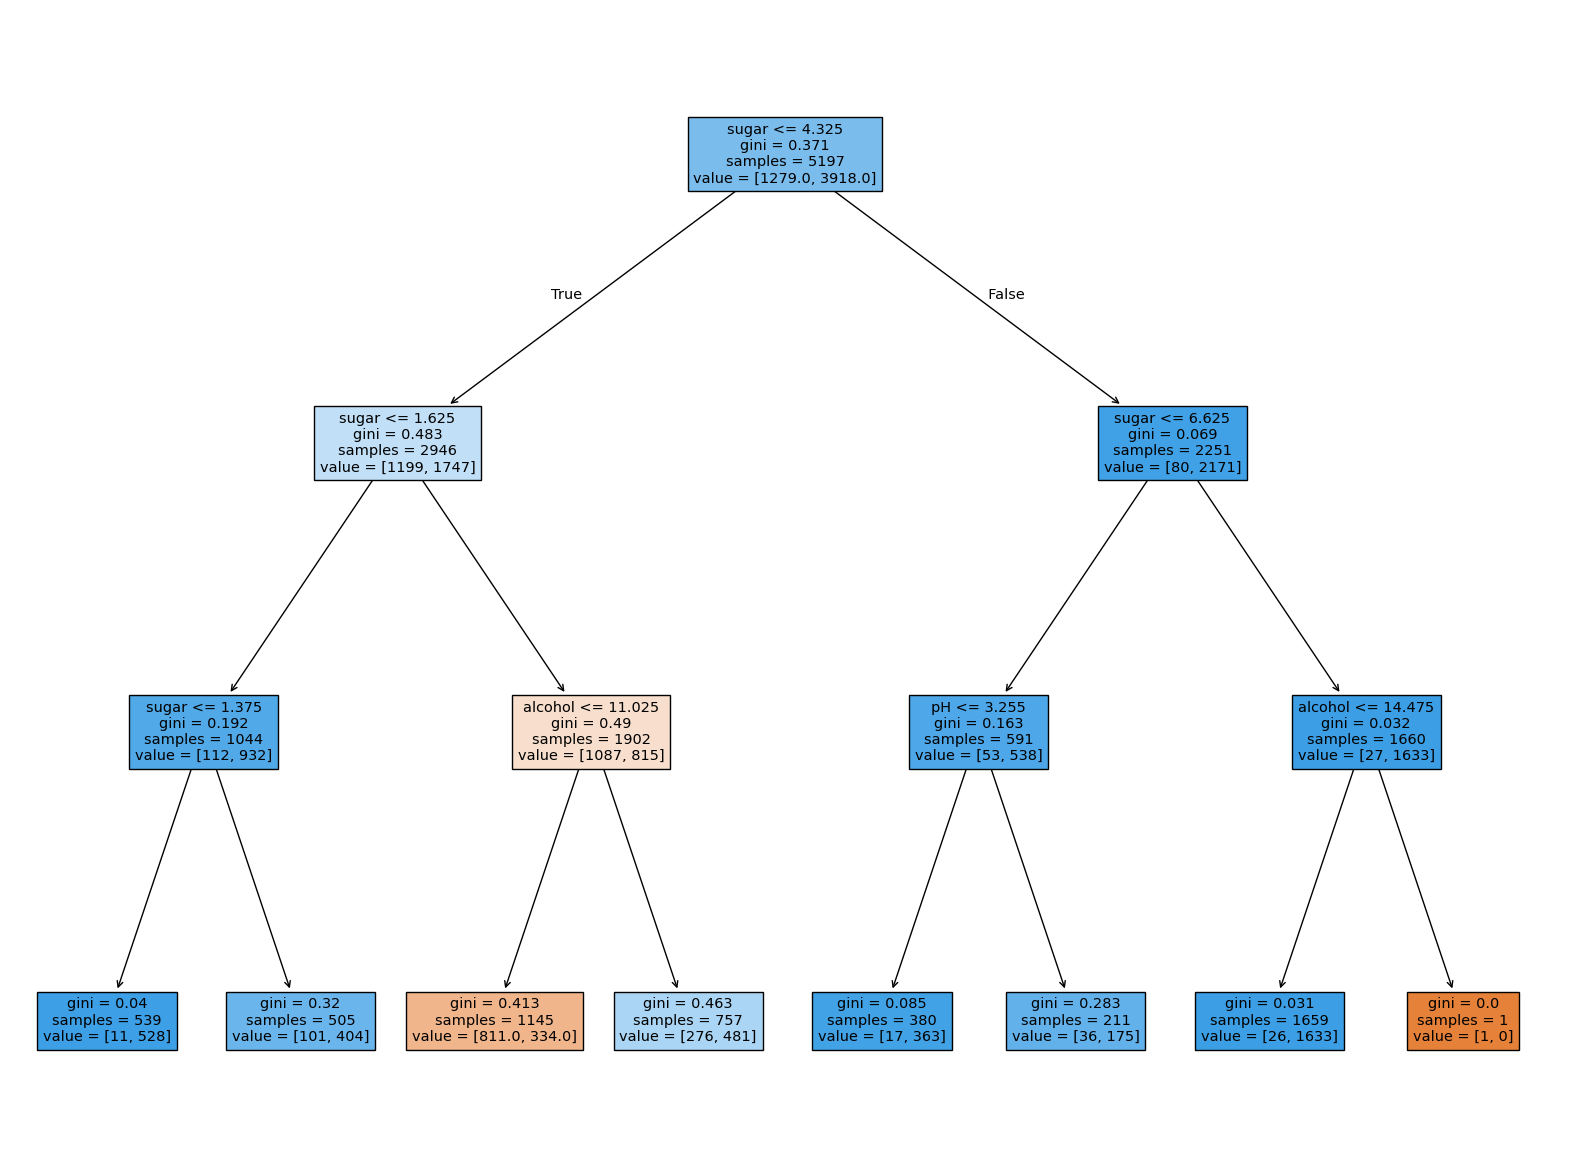

In [22]:
dt2 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt2.fit(train_input, train_target)
print(dt2.score(train_input, train_target))
print(dt2.score(test_input, test_target))
print(dt2.classes_)
print(dt2.feature_names_in_)
print(dt2.feature_importances_)

plt.figure(figsize=(20, 15))
plot_tree(dt2, filled=True, feature_names=train_input.columns)
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB
0.8893592457186839
0.8569230769230769
[0.16163629 0.69101886 0.14734486]
['alcohol' 'sugar' 'pH']


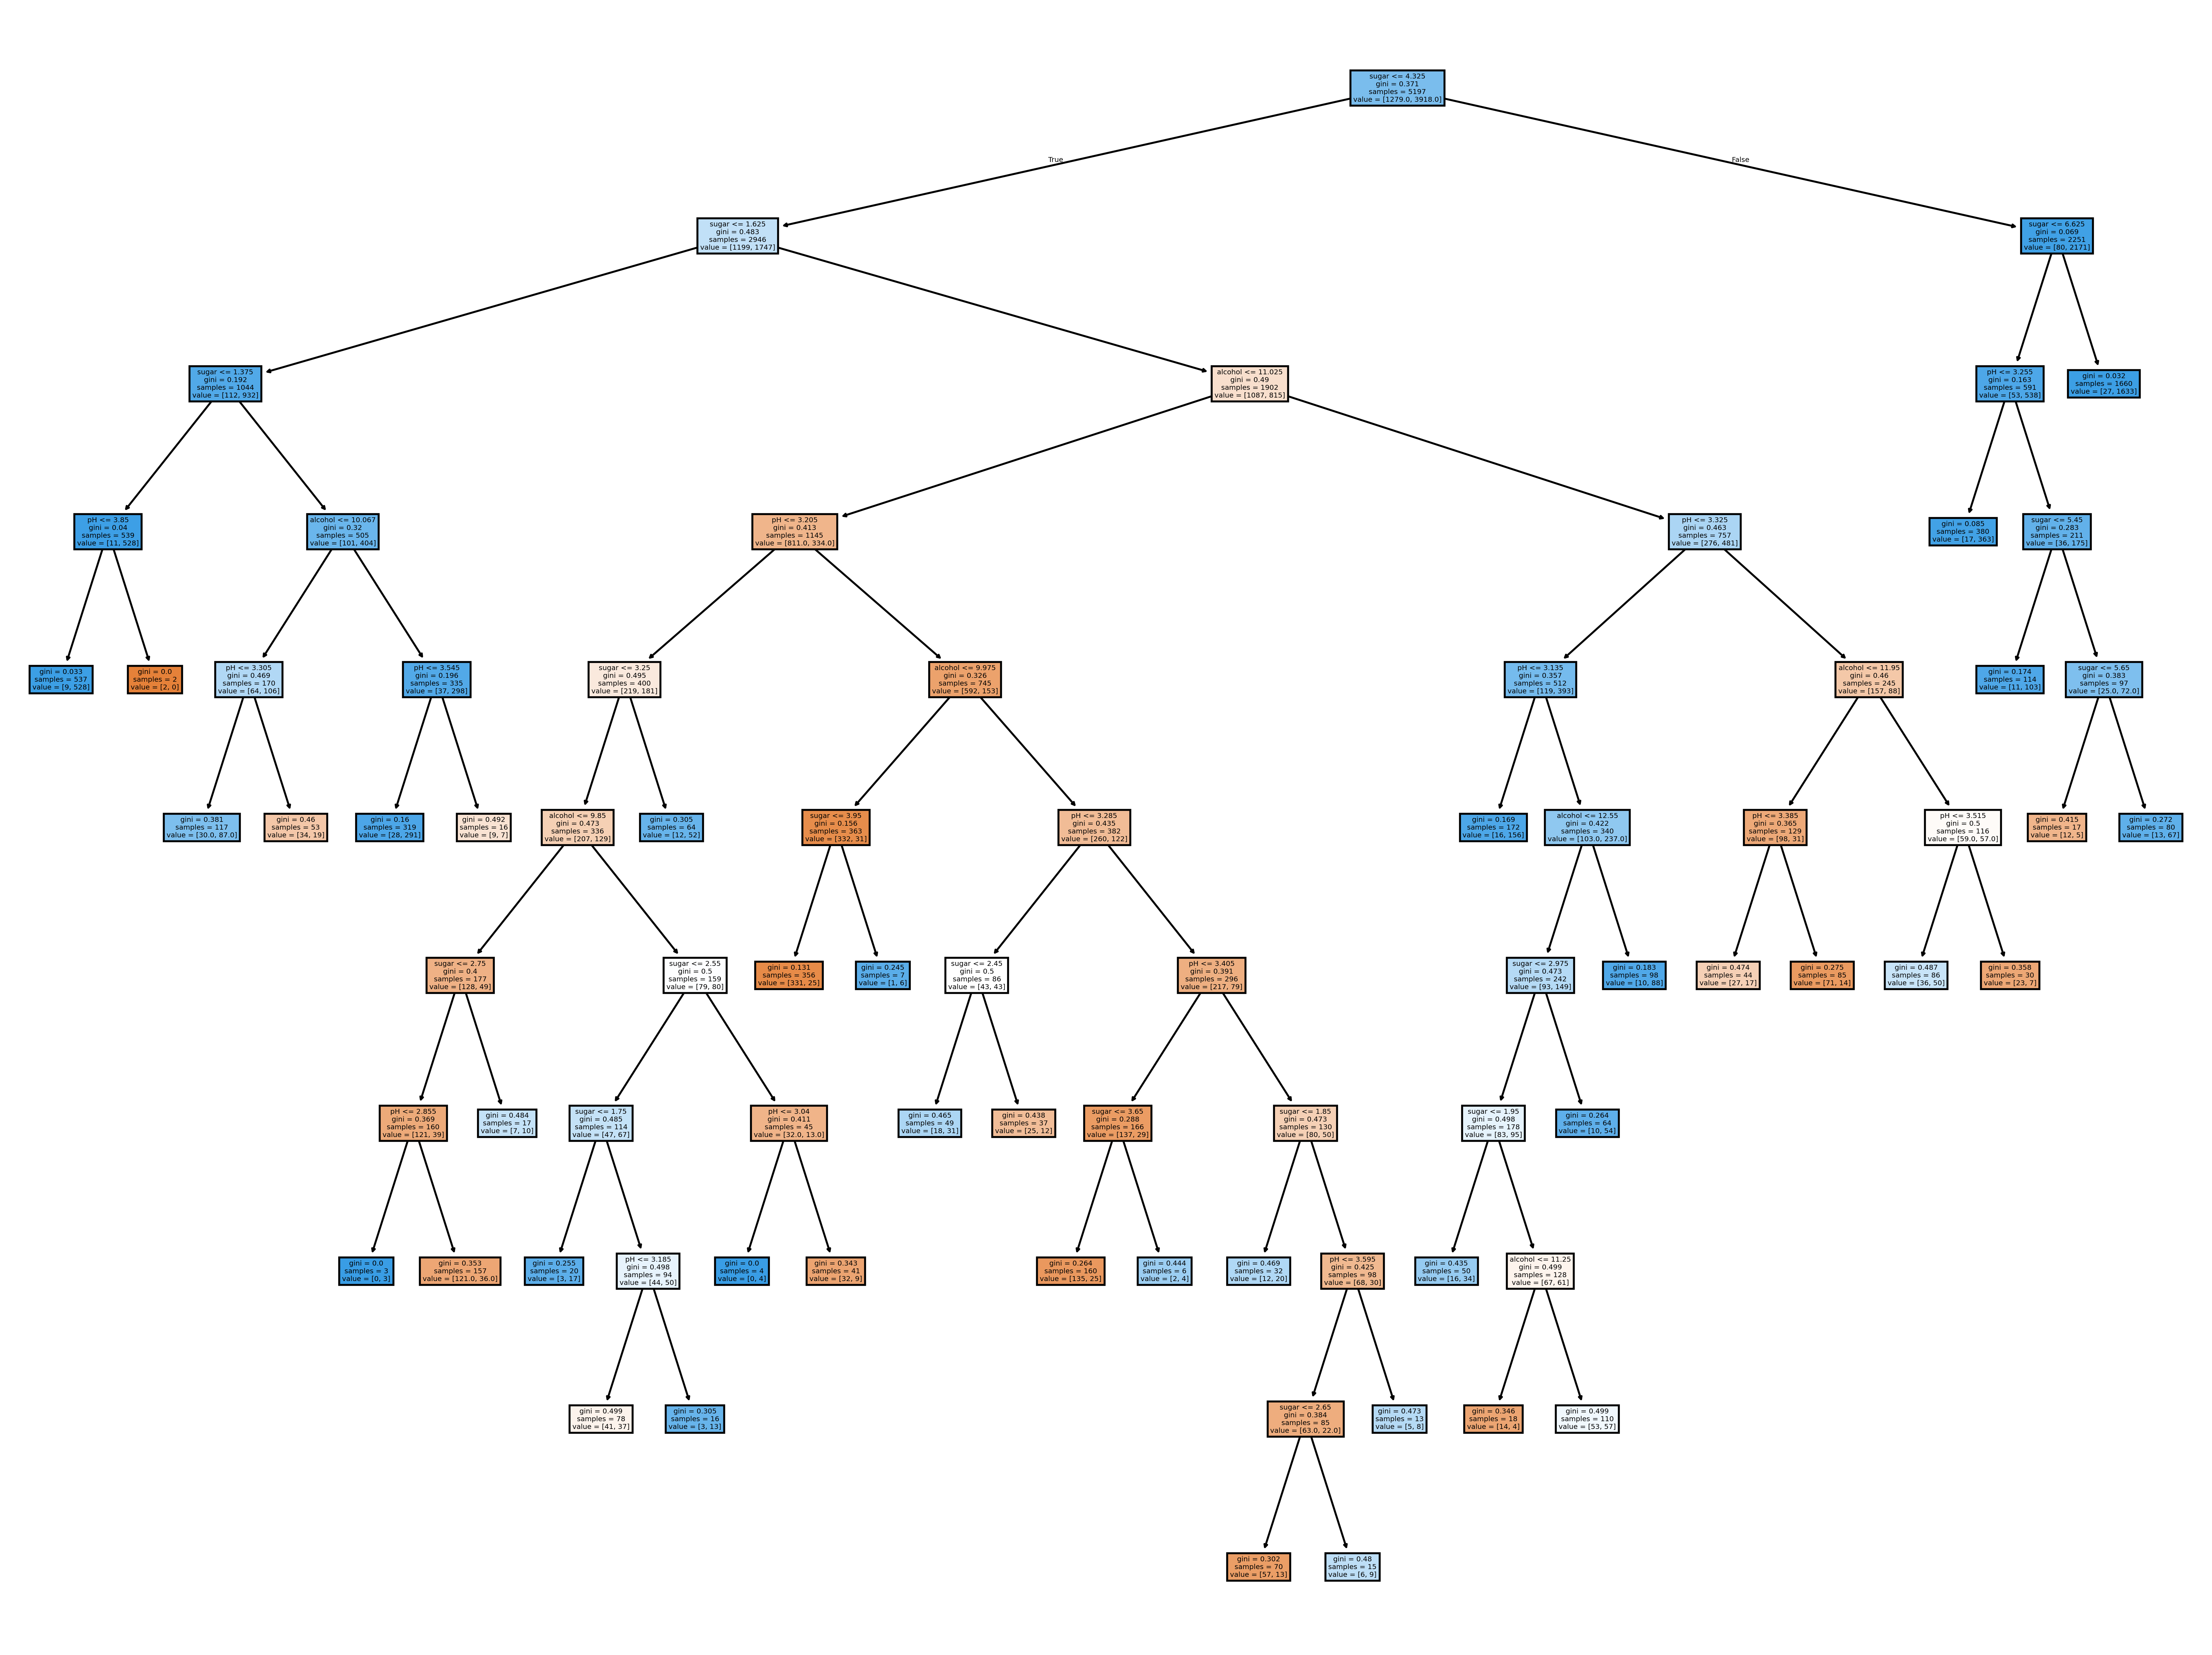

In [44]:
#결정트리모델 DecisionTreeClassifier

import requests
import pandas as pd
from io import StringIO

url=r'https://bit.ly/wine_csv_data'
r = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
r.raise_for_status

wine = pd.read_csv(StringIO(r.text), low_memory=False)
wine.head()
wine.info(memory_usage='deep')
wine.describe(include='all')


from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
dt = DecisionTreeClassifier(criterion='gini', min_impurity_decrease=0.0005)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))
print(dt.feature_importances_)
print(dt.feature_names_in_)

plt.figure(figsize=(20, 15), dpi=400)
plot_tree(dt, filled=True, feature_names=train_input.columns)
plt.show()